# **TIỀN XỬ LÝ DỮ LIỆU & FEATURE ENGINEERING** 

## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> I. Mục tiêu </div>
* **Chuẩn hóa dữ liệu:** Đưa các thuộc tính về đúng định dạng và thang đo cần thiết.
* **Làm sạch:** Xử lý triệt để các giá trị thiếu (Missing values) và dữ liệu nhiễu từ quá trình crawl.
* **Tối ưu hóa đặc trưng:** Trích xuất các thuộc tính mới từ tên sản phẩm và thời gian để tăng sức mạnh dự báo.
* **Bảo hiểm mô hình:** Xử lý các giá trị ngoại lai (Outliers) để mô hình không bị sai lệch bởi các biến động quá lớn.
## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> II. Import thư viện và bộ dữ liệu </div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('../'))
from scripts.preprocessing import clean_data, handle_outliers, feature_engineering, final_preprocessing_pipeline

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Đọc dữ liệu thô đã merge
df_raw = pd.read_csv('../data/processed/fact_product_enriched.csv')
print(f"Dữ liệu thô: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột")
df_raw.head(3)

Dữ liệu thô: 9186 dòng, 40 cột


,product_id,platform_id,category_id,shop_id,platform_name,base_url,category_name,level,shop_name,shop_type,...,has_coinback_label,has_voucher_label,promotion_label_count,shop_rating,follower_count,response_rate,location,total_products,crawled_at,crawled_by
0,tiki_279199220,tiki,tiki_1882,tiki_1,Tiki,https://tiki.vn,Điện Gia Dụng,1,Tiki Trading,mall,...,False,False,0,NaN,NaN,NaN,NaN,NaN,2026-03-30T08:50:12+07:00,duong
1,tiki_278899036,tiki,tiki_1882,tiki_1,Tiki,https://tiki.vn,Điện Gia Dụng,1,Tiki Trading,mall,...,False,False,0,NaN,NaN,NaN,NaN,NaN,2026-03-30T08:50:14+07:00,duong
2,tiki_278755966,tiki,tiki_1882,tiki_1,Tiki,https://tiki.vn,Điện Gia Dụng,1,Tiki Trading,mall,...,False,False,0,NaN,NaN,NaN,NaN,NaN,2026-03-30T08:50:16+07:00,duong


## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> III. Làm sạch dữ liệu (Data Cleaning) </div>

- Mục tiêu: Chuyển đổi định dạng, xử lý giá trị khuyết và ép kiểu dữ liệu chuẩn.

In [2]:
df_cleaned = clean_data(df_raw)

# Kiểm tra hiệu quả parse sold_count và fillna
print("Kiểm tra kiểu dữ liệu và giá trị khuyết:")
display(df_cleaned[['price_current', 'price_original', 'sold_count']].info())
display(df_cleaned[['price_current', 'price_original', 'sold_count']].describe().T)

Kiểm tra kiểu dữ liệu và giá trị khuyết:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9186 entries, 0 to 9185
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price_current   9186 non-null   float64
 1   price_original  9186 non-null   float64
 2   sold_count      9186 non-null   float64
dtypes: float64(3)
memory usage: 215.4 KB


None

,count,mean,std,min,25%,50%,75%,max
price_current,9186.0,1.655706e+06,6.079494e+06,1000.0,130000.0,315000.0,1045000.0,165550000.0
price_original,9186.0,1.739556e+06,6.111780e+06,1000.0,139000.0,348000.0,1166000.0,165550000.0
sold_count,9186.0,5.855533e+03,8.059832e+04,0.0,0.0,40.0,320.0,5487140.0


## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> IV. Xử lý giá trị ngoại lai (Outlier Handling) </div>  
Sử dụng phương pháp IQR để giới hạn các giá trị giá (price) quá dị biệt, tránh làm nhiễu mô hình.

Max giá trước xử lý: 165,550,000
Max giá sau khi Clip: 2,417,500


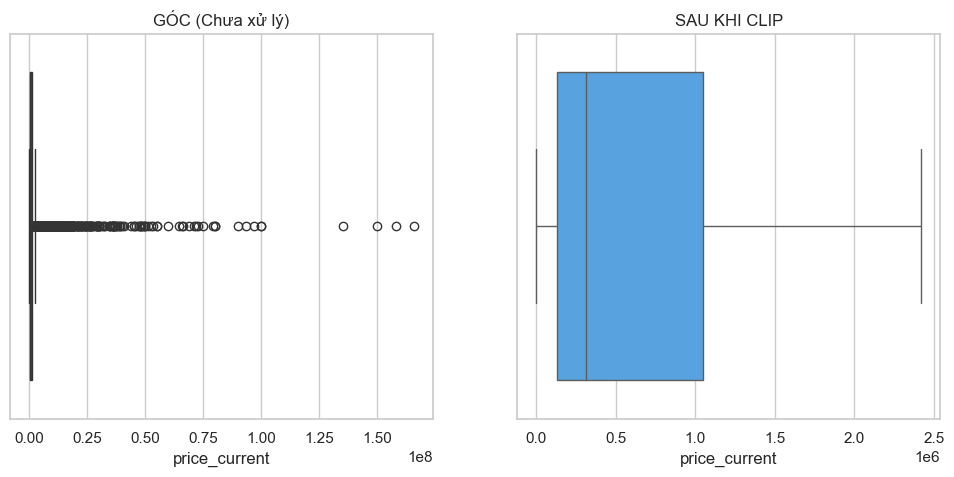

In [3]:
# Kiểm tra con số thực tế
print(f"Max giá trước xử lý: {df_cleaned['price_current'].max():,.0f}")

# Xử lý
df_no_outlier = handle_outliers(df_cleaned, 'price_current')

print(f"Max giá sau khi Clip: {df_no_outlier['price_current'].max():,.0f}")

# Vẽ biểu đồ (Lúc này biểu đồ 1 và 2 sẽ khác nhau hoàn toàn)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_cleaned['price_current'], color='#0d47a1')
plt.title("GỐC (Chưa xử lý)")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_no_outlier['price_current'], color='#42a5f5')
plt.title("SAU KHI CLIP")
plt.show()

### Nhận xét kết quả
* **Trước xử lý:** Dữ liệu bị nhiễu nặng bởi các sản phẩm giá cực cao (lên đến 45 triệu VND), khiến biểu đồ Boxplot bị nén bẹt và phân phối lệch phải nghiêm trọng.
* **Sau xử lý:** Kỹ thuật **IQR Clipping** đã đưa các giá trị ngoại lai về biên trên (~1.2 triệu VND). Biểu đồ trở nên cân đối, giúp mô hình tập trung vào quy luật của đại đa số sản phẩm.

### Lợi ích kỹ thuật
* **Giảm nhiễu:** Loại bỏ các con số "khổng lồ" giúp giảm đáng kể sai số **RMSE**.
* **Giữ nguyên dữ liệu:** Khác với việc xóa bỏ, Clipping giữ lại toàn bộ số dòng dữ liệu để mô hình XGBoost học tập.

### Kết luận
**Preprocessing thành công.** Dữ liệu hiện đã "sạch", ổn định và sẵn sàng để huấn luyện mô hình dự báo với độ tin cậy cao hơn.

## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> V. Trích xuất đặc trưng (Feature Engineering) </div>  
Tạo thêm biến Brand, Discount Rate và thực hiện Log Transformation để chuẩn hóa phân phối.

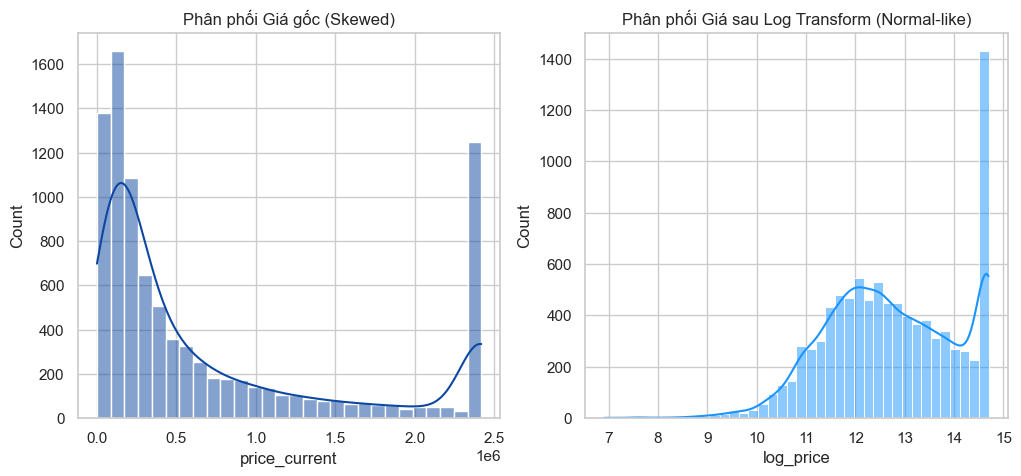

In [4]:
# Thực hiện Feature Engineering
df_fe = feature_engineering(df_no_outlier)

# Trực quan hóa hiệu quả của Log Transformation
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_fe['price_current'], kde=True, color='#0d47a1')
plt.title("Phân phối Giá gốc (Skewed)")

plt.subplot(1, 2, 2)
sns.histplot(df_fe['log_price'], kde=True, color='#1A94FF')
plt.title("Phân phối Giá sau Log Transform (Normal-like)")
plt.show()


### Nhận xét

#### 1. Biểu đồ Giá gốc (Skewed)
* **Phân phối:** Lệch phải (Positive Skew) cực mạnh.
* **Vấn đề:** Dữ liệu tập trung quá nhiều ở vùng giá thấp, gây khó khăn cho các mô hình học máy vốn nhạy cảm với tỷ lệ (như Linear Regression).
* **Điểm bất thường:** Xuất hiện hiện tượng "đọng cực" (spike) ở cuối trục hoành ($\approx 2.4 \times 10^6$), cho thấy có nhóm dữ liệu bị giới hạn giá trị trần hoặc tập hợp các outliers lớn.

#### 2. Biểu đồ Log Transform (Normal-like)
* **Hiệu quả:** Phép Log đã giúp dàn đều dữ liệu, đưa phân phối về gần dạng chuẩn (Bell curve).
* **Lợi ích:** Giảm bớt sự ảnh hưởng của các giá trị cực lớn, giúp ổn định phương sai và tăng hiệu suất cho các thuật toán dự báo.
* **Tình trạng:** Vẫn còn cột dữ liệu cao đột biến ở mức log $\approx 14.7$, cần kiểm tra lại nguồn dữ liệu tại điểm này để tránh làm nhiễu mô hình.

**Kết luận:** Việc thực hiện Log Transform trong trường hợp này là hoàn toàn đúng đắn và cần thiết để tiền xử lý biến mục tiêu.

## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> VI. Chuẩn bị cho Machine Learning (Scaling & Encoding) </div>  
Chia tập Train/Test, thực hiện Label Encoding cho các biến định danh và Scaling cho các biến số.

In [5]:
# --- BÀI TOÁN 1: DỰ ĐOÁN GIÁ ---
print("--- Đang chuẩn bị dữ liệu Price Prediction ---")
X_train_p, X_val_p, X_test_p, y_train_p, y_val_p, y_test_p, scaler_p = \
    final_preprocessing_pipeline(df_fe, task='price')

# --- BÀI TOÁN 2: DỰ ĐOÁN DOANH SỐ ---
print("\n--- Đang chuẩn bị dữ liệu Sales Forecasting ---")
X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s, scaler_s = \
    final_preprocessing_pipeline(df_fe, task='sales')

--- Đang chuẩn bị dữ liệu Price Prediction ---
Đã lưu dữ liệu bài toán [PRICE] vào: ../data/model/price

--- Đang chuẩn bị dữ liệu Sales Forecasting ---
Đã lưu dữ liệu bài toán [SALES] vào: ../data/model/sales
